### Regression Exercise 
# Moneyball The NBA
---

### This HW is not easy. TRY IT YOURSELF FIRST! 
Then If you are able to complete it, [watch this lecture series on it](https://ocw.mit.edu/courses/15-071-the-analytics-edge-spring-2017/pages/linear-regression/playing-moneyball-in-the-nba-recitation/video-1-the-data/). 

In [2]:
# PANDAS IS FOR DATA WRANGLING
import pandas as pd
import numpy as np

# SEABORN IS A PLOTTING LIBRARY
import seaborn as sns

# MATPLOT LIB IS ALSO A PLOTTING LIBRARY
import matplotlib.pyplot as plt

# SKLEARN IS OUR MACHINE LEARNING PACKAGE
from sklearn.linear_model import LinearRegression

# IMPORT OUR RANDOM FOREST REGERSSOR
from sklearn.ensemble import RandomForestRegressor

# METRICS HELP US SCORE OUR MODEL
from sklearn import metrics

# HELP US SPLIT OUR DATA INTO TESTING A TRAINING
from sklearn.model_selection import train_test_split

# Good ol statsmodels
import statsmodels.api as sm

# Specific root mean squared error for stats models
from statsmodels.tools.eval_measures import rmse


from statsmodels.stats.outliers_influence import variance_inflation_factor


from statsmodels.api import qqplot

#import CTPLIB as ctp


# Remember our main steps motto _isbe_.
1. i - Inspect and explore data.
2. s - Select and engineer features.
3. b - Build and train model.
4. e - Evaluate model.

# STEP 1 (i): Inspect and explore data
1. Use `data/NBA_test.csv and data/NBA_train.csv`

In [3]:
# READ IN THE DATA USING PANDAS 
df_train = pd.read_csv('/workspaces/ds-fall-2025-fri-1230/Week-08-Regression/data/NBA_train.csv')
df_test = pd.read_csv('/workspaces/ds-fall-2025-fri-1230/Week-08-Regression/data/NBA_test.csv')


# DISPLAY THE FIRST 5 ROWS
print(df_train.head())
print("-------------------------------------------------------------------------------")
print(df_test.head())

   SeasonEnd                 Team  Playoffs   W   PTS  oppPTS    FG   FGA  \
0       1980        Atlanta Hawks         1  50  8573    8334  3261  7027   
1       1980       Boston Celtics         1  61  9303    8664  3617  7387   
2       1980        Chicago Bulls         0  30  8813    9035  3362  6943   
3       1980  Cleveland Cavaliers         0  37  9360    9332  3811  8041   
4       1980       Denver Nuggets         0  30  8878    9240  3462  7470   

     2P   2PA   3P  3PA    FT   FTA   ORB   DRB   AST  STL  BLK   TOV  
0  3248  6952   13   75  2038  2645  1369  2406  1913  782  539  1495  
1  3455  6965  162  422  1907  2449  1227  2457  2198  809  308  1539  
2  3292  6668   70  275  2019  2592  1115  2465  2152  704  392  1684  
3  3775  7854   36  187  1702  2205  1307  2381  2108  764  342  1370  
4  3379  7215   83  255  1871  2539  1311  2524  2079  746  404  1533  
-------------------------------------------------------------------------------
   SeasonEnd             

```
SeasonEnd: Year season ended
Team: Name of team
Playoffs: If they made the playoffs. 1 == made to playoffs
W: Number of regular season in that season. 
PTS: Points scored in regular season. 
oppPTS: Opponent Points scored in regular season. 
FG: Field Goals made (total shots made == 2P and 3P combined)
FGA: Field Goals attempted (total shots attempted == 2P and 3P combined)
2P: two-pointers made
2PA: two-pointers attempted
3P: three-pointers made
3PA: three-pointers attempted
FT: Free-Throws made (not included in FG stat)
FTA: Free-Throws attempted (not included in FG stat)
ORB: Offensive Rebounds
DRB: Defensive Rebounds
AST: Assists made
STL: Steals 
BLK: Blocks 
TOV: Turnovers 
```

#### Inspect our data using `df.describe()` function.

In [4]:
# Inspect our data using `df.describe()` function.
print(df_train.describe())
print(df_test.describe())

         SeasonEnd    Playoffs           W           PTS        oppPTS  \
count   835.000000  835.000000  835.000000    835.000000    835.000000   
mean   1996.319760    0.574850   41.000000   8370.239521   8370.239521   
std       9.243808    0.494662   12.740822    581.040114    587.543959   
min    1980.000000    0.000000   11.000000   6901.000000   6909.000000   
25%    1989.000000    0.000000   31.000000   7934.000000   7934.000000   
50%    1996.000000    1.000000   42.000000   8312.000000   8365.000000   
75%    2005.000000    1.000000   50.500000   8784.500000   8768.500000   
max    2011.000000    1.000000   72.000000  10371.000000  10723.000000   

                FG          FGA           2P          2PA          3P  \
count   835.000000   835.000000   835.000000   835.000000  835.000000   
mean   3200.367665  6873.318563  2881.324551  5956.444311  319.043114   
std     287.181266   401.027166   446.097941   830.596327  199.698941   
min    2565.000000  5972.000000  1981.000

#### Check for Nulls.

In [5]:
# Check for Nulls.
print(df_train.isnull().sum())
print(df_test.isnull().sum())

SeasonEnd    0
Team         0
Playoffs     0
W            0
PTS          0
oppPTS       0
FG           0
FGA          0
2P           0
2PA          0
3P           0
3PA          0
FT           0
FTA          0
ORB          0
DRB          0
AST          0
STL          0
BLK          0
TOV          0
dtype: int64
SeasonEnd    0
Team         0
Playoffs     0
W            0
PTS          0
oppPTS       0
FG           0
FGA          0
2P           0
2PA          0
3P           0
3PA          0
FT           0
FTA          0
ORB          0
DRB          0
AST          0
STL          0
BLK          0
TOV          0
dtype: int64


#### Check for Duplicates

In [6]:
# Check for Duplicates
print(df_train.duplicated().sum())
print(df_test.duplicated().sum())

0
0


#### Build a function that will INSPECT ANY DATAFRAME FOR YOU do this for you for any data frame you pass into it.

In [11]:
def inspect_dataframe(input_df):
    """
    Display key information about a DataFrame:
    - Shape and column count
    - Missing values
    - Duplicate rows
    - Data types
    - Descriptive statistics
    """
    divider = '-' * 40
    print(f"\n{divider}\nDataframe Info \n{divider}\n")

    # Dimensions
    rows, cols = input_df.shape
    print("Shape:")
    print(f"Rows: {rows:,}")
    print(f"Columns: {cols}\n")

     # Summary statistics
    print("Combined summary:")
    print(input_df.describe())
    print(f"\n{divider}")

    # Missing values
    print("Null Values:")
    missing = input_df.isna().sum()
    if missing.any():
        print(missing[missing > 0])
    else:
        print("No nulls")
    print()

       # Data types
    print("Datatypes:")
    print(input_df.dtypes.to_string())
    print()

    # Duplicates
    print("Duplicate rows:")
    duplicates = input_df.duplicated().sum()
    print(f"  {duplicates} duplicate row(s)\n")


   



# Example usage
inspect_dataframe(df_train)





----------------------------------------
Dataframe Info 
----------------------------------------

Shape:
Rows: 835
Columns: 20

Combined summary:
         SeasonEnd    Playoffs           W           PTS        oppPTS  \
count   835.000000  835.000000  835.000000    835.000000    835.000000   
mean   1996.319760    0.574850   41.000000   8370.239521   8370.239521   
std       9.243808    0.494662   12.740822    581.040114    587.543959   
min    1980.000000    0.000000   11.000000   6901.000000   6909.000000   
25%    1989.000000    0.000000   31.000000   7934.000000   7934.000000   
50%    1996.000000    1.000000   42.000000   8312.000000   8365.000000   
75%    2005.000000    1.000000   50.500000   8784.500000   8768.500000   
max    2011.000000    1.000000   72.000000  10371.000000  10723.000000   

                FG          FGA           2P          2PA          3P  \
count   835.000000   835.000000   835.000000   835.000000  835.000000   
mean   3200.367665  6873.318563  2881.3

#### Get a sense of how many wins it will take to make the playoffs. 
Make a scatter plot with x=Wins and the y=Team, and the hue=Playoffs

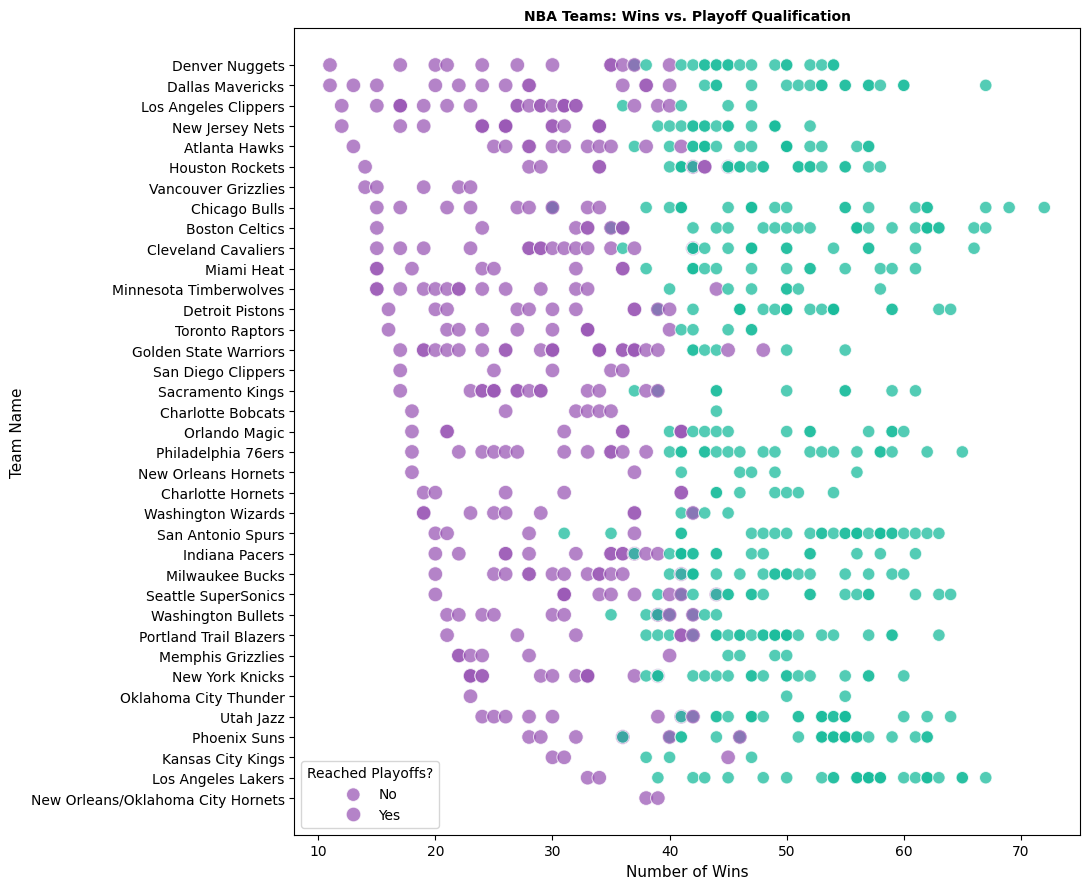

In [ ]:
# I sorted teams by wins
df_sorted = df_train.sort_values(by='W', ascending=True)

# Here I specified basic size of the figure
plt.figure(figsize=(11, 9))
# Plot in Scatter to visualize teams and their wins
sns.scatterplot(
    data=df_sorted, 
    x='W', 
    y='Team', 
    hue='Playoffs', 
    palette={0: '#9b59b6', 1: '#1abc9c'},  # purple & teal
    size='Playoffs', 
    sizes=(80, 110), 
    alpha=0.75
)


# I added plot title and axis labels, customized legend and displayed the scatter
plt.title('NBA Teams: Wins vs. Playoff Qualification', fontsize=10, weight='semibold')
plt.xlabel('Number of Wins', fontsize=11)
plt.ylabel('Team Name', fontsize=11)
plt.legend(title='Reached Playoffs?', labels=['No', 'Yes'])
plt.tight_layout()
plt.show()

#### Take a rough estimate, and now use that moving forward.  



In [8]:
WINS_NEED_TO_MAKE_PLAYOFFS = ???

SyntaxError: invalid syntax (2784417354.py, line 1)

---

# Now do moneyball but for the NBA. 

#### I would like you to do try and do this on your own first.  

It's not easy, but its fun af.  

There is a guided lecture on how to do this that I can send you, but I'd like for you to try and figure it out on your own first.  

If you are fully stuck, ask in slack how other people did it if that doesn't work (I highly encourage collorbration and learning from eachother.  I still consider that doing it on your own.)  

If that doesn't work, DM me and I will send you the lectures explaining how to do the whole thing.

# Rough Guide a v1 model.
0. Make a model to predict PTS 
0. For v1, dont use `2P, 3P, FG, or FT`.  Instead use `2PA, 3PA, FTA`.  
0. Include any other cols use see fit.  
